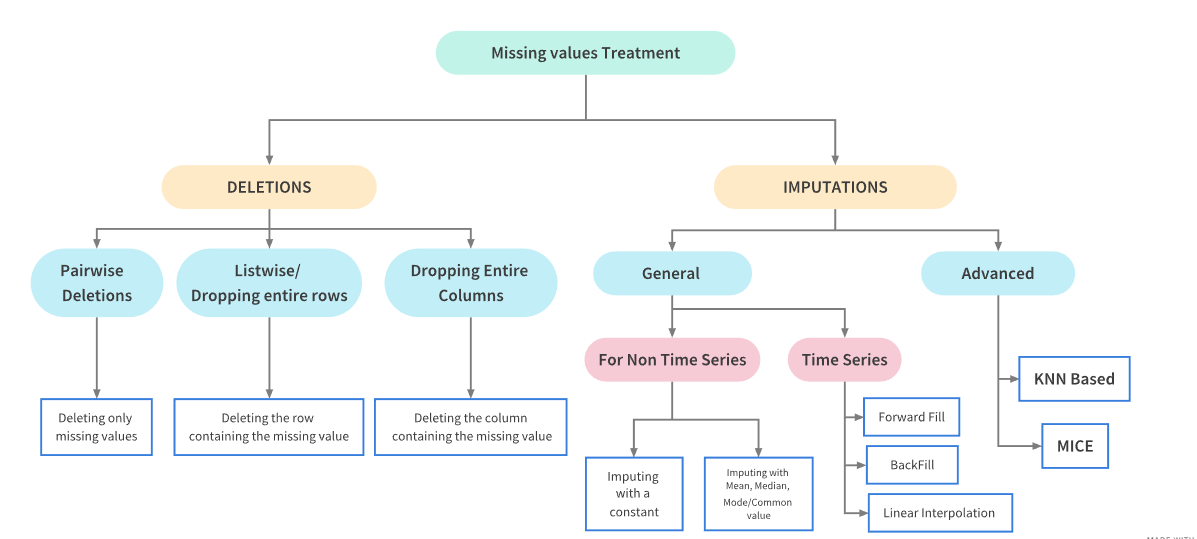

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
import missingno as msno

In [7]:
train=pd.read_csv('/kaggle/input/Tutorials/train.csv')
test=pd.read_csv('/kaggle/input/Tutorials/test.csv')

In [8]:
print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


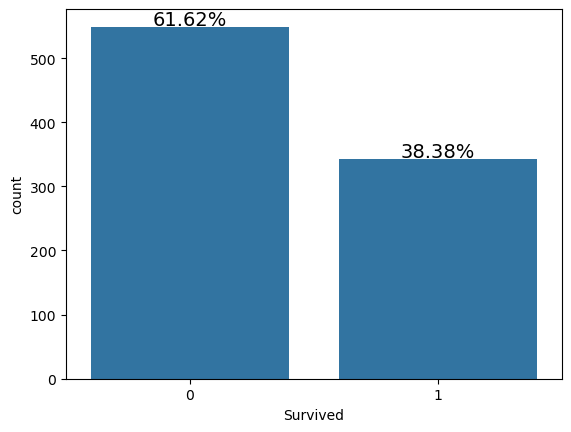

In [16]:
s = sns.countplot(x = 'Survived',data = train)
sizes=[]
for p in s.patches:
    height = p.get_height()
    sizes.append(height)
    s.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/len(train)*100),
            ha="center", fontsize=14) 

    


In [21]:
def missing_values_table(df):
    mis_val=df.isnull().sum()
    mis_val_percent=100 * df.isnull().sum()/len(df)
    mis_val_table=pd.concat([mis_val,mis_val_percent],axis=1)
    mis_val_rename_table_columns=mis_val_table.rename(columns={0:'Missing_values',1:'Total Missing Values Percentage'})
    mis_val_rename_table_columns=mis_val_rename_table_columns[mis_val_rename_table_columns.iloc[:,1]!=0].sort_values(by='Total Missing Values Percentage',ascending=False).round(1)
    return mis_val_rename_table_columns


In [ ]:
train_missing=missing_values_table(train)
print(train_missing)

,Missing_values,Total Missing Values Percentage
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
